# RNN Models
Composed of 3 models (one trained on all data, one on critics, one on users)

## Setup
Ensure that pytorch is installed first, as well as any other dependencies

In [1]:
%pip install langdetect kaggle

import copy
import io
import random
import re
import shutil
import time
from time import perf_counter
import unicodedata
import urllib.request
import zipfile
from pathlib import Path
import langdetect
from tempfile import TemporaryDirectory
import subprocess
from sysconfig import get_path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Subset, random_split, DataLoader, Dataset, ConcatDataset
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Selected device:", DEVICE)

PAD, UNK = 0, 1
MAX_SENTENCE_TOKENS = 9
MAX_PAIRS = 3000
BATCH_SIZE = 64
EPOCHS=50

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993335 sha256=1b221c3209654582c14bf03af49dafbab939bf98d98e2485afc76f447c32e149
  Stored in directory: /root/.cache/pip/wheels/eb/87/25/2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect
Selected device: cuda


### Helper Functions

In [2]:
def label_to_score(label):
    return label * 10

def score_to_label(score):
    return score // 10

@torch.no_grad
def predict_score(review, model, vocab, device=DEVICE):
    model.eval()
    tokens = vocab.encode(review)
    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    src_lengths = torch.tensor([len(tokens)], dtype=torch.long).to(device)
    logits = model(src, src_lengths)
    label = logits.squeeze(-1).item()
    return label_to_score(label)

## Vocabulary and Minibatches

### Vocab

In [3]:
class Vocab:
    def __init__(self):
        self.word2id = {"<pad>": PAD, "<unk>": UNK}
        self.id2word = {PAD: "<pad>", UNK: "<unk>"}

    def __len__(self):
        return len(self.word2id)

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2id:
                id = len(self.word2id)
                self.word2id[word] = id
                self.id2word[id] = word

    def encode(self, sentence):
        return [self.word2id.get(word, UNK) for word in sentence.split()]

### Dataset

In [4]:
class MovieReviewDataset(Dataset):
    def __init__(self, reviews, scores, vocab):
        self.reviews = reviews
        self.scores = scores
        self.vocab = vocab

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, index):
        text = self.vocab.encode(self.reviews[index])
        label = float(score_to_label(self.scores[index]))
        return text, label

### Collate

In [5]:
def collate(batch):
    src_sequences = []
    src_lengths = []
    labels = []
    for src, label in batch:
        src_sequences.append(torch.tensor(src, dtype=torch.long))
        src_lengths.append(len(src))
        labels.append(label)
    src = pad_sequence(src_sequences, batch_first=True, padding_value=PAD)
    src_lengths = torch.tensor(src_lengths, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.float32)
    return src, src_lengths, labels

## Preprocessing

In [6]:
# Grab reviews of specific type
def reviews_by_type(df, review_type_column="review_type", target_type="BOTH"):
    if review_type_column not in df.columns:
        raise ValueError(
            f"Review type column {review_type_column!r} not found. "
            f"Available columns: {', '.join(map(str, df.columns))}"
        )

    types = df[review_type_column].astype(str).str.strip().str.casefold()
    return df.loc[types == target_type.strip().casefold()].copy()

# Grab COUNT samples that are in english
def english_sample(group, review_column, count):
    # Randomize the order so we don't always inspect the same rows first.
    shuffled = group.sample(frac=1, random_state=SEED)
    english_indices = []

    for index, text in shuffled[review_column].items():
        if isinstance(text, str) and text.strip():
            try:
                if langdetect.detect(text) == "en":
                    english_indices.append(index)
                    if len(english_indices) == count:
                        break
            except langdetect.LangDetectException:
                pass

    if len(english_indices) < count:
        raise ValueError(
            f"Found only {len(english_indices)} English reviews; "
            f"needed {count}. Increase the available data or lower the requested count."
        )

    return shuffled.loc[english_indices].copy()

# Creates the datasets for training, validation, and testing
def make_loaders(dataset, batch_size=BATCH_SIZE, total_entries=None):
    if total_entries is None:
        total_entries = len(dataset)

    if total_entries < 10:
        raise ValueError("total_entries must be at least 10.")
    if total_entries > len(dataset):
        raise ValueError(
            f"Requested {total_entries} entries, but the dataset has "
            f"only {len(dataset)}."
        )

    selection_generator = torch.Generator().manual_seed(SEED)
    indices = torch.randperm(
        len(dataset), generator=selection_generator
    )[:total_entries].tolist()

    selected_dataset = Subset(dataset, indices)

    train_size = int(0.8 * total_entries)
    val_size = int(0.1 * total_entries)
    test_size = total_entries - train_size - val_size

    train_set, val_set, test_set = random_split(
        selected_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED + 1),
    )

    return (
        DataLoader(
            train_set, batch_size=batch_size, shuffle=True, collate_fn=collate
        ),
        DataLoader(
            val_set, batch_size=batch_size, collate_fn=collate
        ),
        DataLoader(
            test_set, batch_size=batch_size, collate_fn=collate
        ),
    )

def prepare_group(
    df,
    type_value,
    entries_per_group,
    review_type_column="review_type",
    review_column="quote",
    score_column="score",
    score_multiplier=1,
):
    group = reviews_by_type(
        df,
        review_type_column=review_type_column,
        target_type=type_value,
    )

    group[score_column] = pd.to_numeric(group[score_column], errors="coerce")
    group = group.dropna(subset=[review_column, score_column]).copy()
    group[score_column] *= score_multiplier
    group = group[group[score_column].between(0, 100)]

    # Select the requested number of English reviews from this group.
    group = english_sample(group, review_column, entries_per_group)

    reviews = group[review_column].astype(str).tolist()
    scores = group[score_column].tolist()
    return reviews, scores

# Builds loaders for groups (users, critics)
def build_group_loaders(
    df,
    type_value,
    entries_per_group,
    review_type_column="review_type",
    review_column="quote",
    score_column="score",
    score_multiplier=1,
):
    reviews, scores = prepare_group(
        df,
        type_value=type_value,
        entries_per_group=entries_per_group,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        score_multiplier=score_multiplier,
    )

    vocab = Vocab()
    for review in reviews:
        vocab.add_sentence(review)

    dataset = MovieReviewDataset(reviews, scores, vocab)
    loaders = make_loaders(dataset, total_entries=entries_per_group)
    return loaders, vocab

# Build loader that uses user/critic split
def build_both_loaders(
    df,
    entries_per_source,
    review_type_column="review_type",
    review_column="quote",
    score_column="score",
    user_score_multiplier=1,
    critic_score_multiplier=1,
    batch_size=BATCH_SIZE,
):
    user_reviews, user_scores = prepare_group(
        df,
        type_value="user",
        entries_per_group=entries_per_source,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        score_multiplier=user_score_multiplier,
    )

    critic_reviews, critic_scores = prepare_group(
        df,
        type_value="critic",
        entries_per_group=entries_per_source,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        score_multiplier=critic_score_multiplier,
    )

    # Both sources share one vocabulary for the combined model.
    both_vocab = Vocab()
    for review in user_reviews + critic_reviews:
        both_vocab.add_sentence(review)

    user_dataset = MovieReviewDataset(user_reviews, user_scores, both_vocab)
    critic_dataset = MovieReviewDataset(critic_reviews, critic_scores, both_vocab)

    # Split each source separately so every split has equal user/critic counts.
    user_splits = make_loaders(user_dataset, total_entries=entries_per_source)
    critic_splits = make_loaders(critic_dataset, total_entries=entries_per_source)

    combined_sets = [
        ConcatDataset([user_splits[i].dataset, critic_splits[i].dataset])
        for i in range(3)
    ]

    both_loaders = (
        DataLoader(
            combined_sets[0],
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collate,
        ),
        DataLoader(
            combined_sets[1],
            batch_size=batch_size,
            collate_fn=collate,
        ),
        DataLoader(
            combined_sets[2],
            batch_size=batch_size,
            collate_fn=collate,
        ),
    )

    return both_loaders, both_vocab

# Load training, validation, testing sets

In [7]:
kaggle_exe = shutil.which("kaggle")
if kaggle_exe is None:
    raise FileNotFoundError("Kaggle CLI not found. Run %pip install kaggle.")

dataset_id = "davutb/metacritic-movies"
csv_filename = "movies_reviews.csv"

# For "both" group, this means 20,000, because there's 10,000 per GROUP
entries_per_group = 10_000

review_column = "quote"
score_column = "score"
review_type_column = "review_type"

# Load kaggle dataset temporarily
with TemporaryDirectory() as temp_dir:
    subprocess.run(
        [
            kaggle_exe,
            "datasets", "download", dataset_id,
            "-f", csv_filename,
            "-p", temp_dir,
            "--unzip",
        ],
        check=True,
    )

    csv_files = list(Path(temp_dir).rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV found; check {csv_filename!r}.")

    # Read the CSV once
    df = pd.read_csv(csv_files[0])
    print(df[review_type_column].value_counts(dropna=False))

    user_loaders, user_vocab = build_group_loaders(
        df,
        type_value="user",
        entries_per_group=entries_per_group,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        score_multiplier=1,
    )

    critic_loaders, critic_vocab = build_group_loaders(
        df,
        type_value="critic",
        entries_per_group=entries_per_group,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        score_multiplier=1,
    )

    both_loaders, both_vocab = build_both_loaders(
        df,
        entries_per_source=entries_per_group,
        review_type_column=review_type_column,
        review_column=review_column,
        score_column=score_column,
        user_score_multiplier=1,
        critic_score_multiplier=1,
    )

# Get loaders for user, critic, and both groups
user_train_loader, user_val_loader, user_test_loader = user_loaders
critic_train_loader, critic_val_loader, critic_test_loader = critic_loaders
both_train_loader, both_val_loader, both_test_loader = both_loaders

category_loaders = {
    "User": user_loaders,
    "Critic": critic_loaders,
    "Both": both_loaders,
}

# Print labels, counts, and distribution information
for name, loaders in category_loaders.items():
    labels = [
        int(loader.dataset[i][1])
        for loader in loaders
        for i in range(len(loader.dataset))
    ]
    counts = Counter(labels)
    majority_baseline = max(counts.values()) / len(labels)

    print(
        f"{name}: label counts={dict(sorted(counts.items()))} | "
        f"majority-class baseline={majority_baseline:.1%}"
    )

review_type
user      338950
critic    328586
Name: count, dtype: int64
User: label counts={0: 655, 1: 377, 2: 438, 3: 454, 4: 487, 5: 679, 6: 909, 7: 1146, 8: 1436, 9: 1257, 10: 2162} | majority-class baseline=21.6%
Critic: label counts={0: 50, 1: 89, 2: 421, 3: 595, 4: 759, 5: 1622, 6: 1583, 7: 2122, 8: 1661, 9: 525, 10: 573} | majority-class baseline=21.2%
Both: label counts={0: 705, 1: 466, 2: 860, 3: 1048, 4: 1247, 5: 2302, 6: 2491, 7: 3266, 8: 3097, 9: 1781, 10: 2737} | majority-class baseline=16.3%


## RNN Model

### Cell

In [8]:
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_linear = nn.Linear(input_size, hidden_size)
        self.hidden_linear = nn.Linear(hidden_size, hidden_size)

    def forward(self, x_t, h_prev):
        input = self.input_linear(x_t)
        hidden = self.hidden_linear(h_prev)
        state = input + hidden
        return torch.tanh(state)

### Encoder

In [9]:
class Encoder(nn.Module):
    def __init__(self, source_vocab_size, embedding_dim,
                 hidden_size, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(
            source_vocab_size, embedding_dim, padding_idx=PAD
        )
        self.dropout = nn.Dropout(dropout)
        self.cell = RNNCell(input_size=embedding_dim, hidden_size=hidden_size)

    def forward(self, src, src_length):
        embedded = self.dropout(self.embedding(src))
        batch_size = src.size(0)
        h = embedded.new_zeros(batch_size, self.hidden_size)
        for t in range(src.size(1)):
            proposal = self.cell(embedded[:, t], h)
            mask = (t < src_length).unsqueeze(1)
            h = torch.where(mask, proposal, h)
        return h

### Score Classifier

In [10]:
class ScoreClassifier(nn.Module):
    def __init__(self, source_vocab_size, embedding_dim,
                 hidden_size, dropout=0.1, num_classes=1):
        super().__init__()
        self.encoder = Encoder(source_vocab_size, embedding_dim, hidden_size, dropout)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, src, src_lengths):
        encoder = self.encoder(src, src_lengths)
        logits = self.classifier(encoder)
        return logits

## CNN Score Classifier

In [11]:
class CNNScoreClassifier(nn.Module):
    def __init__(
        self, source_vocab_size, embedding_dim, hidden_size,
        dropout=0.1, num_classes=11, kernel_sizes=(3, 5, 7)
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            source_vocab_size, embedding_dim, padding_idx=PAD
        )
        self.convolutions = nn.ModuleList([
            nn.Conv1d(
                embedding_dim, hidden_size,
                kernel_size=size, padding=size // 2
            )
            for size in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            hidden_size * len(kernel_sizes), 1
        )

    def forward(self, src, src_lengths):
        embedded = self.embedding(src).transpose(1, 2)
        positions = torch.arange(src.size(1), device=src.device).unsqueeze(0)
        valid_positions = positions < src_lengths.unsqueeze(1)

        pooled = []
        for convolution in self.convolutions:
            activations = torch.relu(convolution(embedded))
            activations = activations.masked_fill(
                ~valid_positions.unsqueeze(1),
                torch.finfo(activations.dtype).min,
            )
            pooled.append(activations.max(dim=2).values)

        features = torch.cat(pooled, dim=1)
        return self.classifier(self.dropout(features))

## Training and Validation

### Training One Epoch

In [12]:
def train_one_epoch(model, loader, criterion,
                    optimizer, device, clip_value=1.0):
    model.train()
    total_loss = 0.0
    total_mae = 0
    total_tokens = 0
    for src, src_lengths, labels in loader:
        src, src_lengths, labels = src.to(device), src_lengths.to(device), labels.to(device).float()
        optimizer.zero_grad()
        logits = model(src, src_lengths).squeeze(-1)
        loss = criterion(logits, labels)
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=clip_value)
        optimizer.step()
        # Since it is regression, the prediction is the raw logit itself (rounded to the nearest index for MAE tracking)
        predictions = torch.round(logits).clamp(0, 10)
        total_loss += loss.item() * src.size(0)
        total_mae += torch.abs(predictions - labels).sum().item()
        total_tokens += src.size(0)
    return total_loss / total_tokens, total_mae / total_tokens

### Evaluate

In [13]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = total_mae = total_tokens = 0
    for src, src_lengths, labels in loader:
        src, src_lengths, labels = src.to(device), src_lengths.to(device), labels.to(device).float()
        logits = model(src, src_lengths).squeeze(-1)
        loss = criterion(logits, labels)
        # Use raw prediction rounded to nearest class index
        predictions = torch.round(logits).clamp(0, 10)
        total_loss += float(loss.item()) * src.size(0)
        total_mae += torch.abs(predictions - labels).sum().item()
        total_tokens += src.size(0)
    return total_loss / total_tokens, total_mae / total_tokens

### Fit Model

In [14]:
def fit_model(model, train_loader, val_loader, epochs=EPOCHS, patience=4, lr=1e-3,
              weight_decay=1e-4, clip_value=1.0, device=DEVICE, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    history = {
        "train_loss": [],
        "train_mae": [],
        "val_loss": [],
        "val_mae": [],
    }

    best_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, clip_value
        )
        va_loss, va_acc = evaluate(
            model, val_loader, criterion, device
        )

        for key, value in (
            ("train_loss", tr_loss),
            ("train_mae", tr_acc),
            ("val_loss", va_loss),
            ("val_mae", va_acc),
        ):
            history[key].append(value)

        if va_loss < best_loss:
            best_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f} | val loss {va_loss:.4f} | "
                f"train mae {tr_acc:.4f} | val mae {va_acc:.4f}"
            )

        # Early stopping with patience
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping after epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    return history

## CNN Evaluation

In [15]:
cnn_loaders = {
    "User": (user_train_loader, user_val_loader, user_test_loader),
    "Critic": (critic_train_loader, critic_val_loader, critic_test_loader),
    "Both": (both_train_loader, both_val_loader, both_test_loader),
}
cnn_vocabs = {
    "User": user_vocab,
    "Critic": critic_vocab,
    "Both": both_vocab,
}

cnn_models = {}
cnn_histories = {}

for name, (train_loader, val_loader, _) in cnn_loaders.items():
    cnn_models[name] = CNNScoreClassifier(
        source_vocab_size=len(cnn_vocabs[name]),
        embedding_dim=64,
        hidden_size=64,
    )
    print(f"\n{'=' * 15} {name.upper()} CNN {'=' * 15}")
    cnn_histories[name] = fit_model(
        cnn_models[name], train_loader, val_loader, epochs=EPOCHS, patience=4
    )

criterion = nn.MSELoss()
for name, (_, _, test_loader) in cnn_loaders.items():
    test_loss, test_accuracy = evaluate(
        cnn_models[name], test_loader, criterion, DEVICE
    )
    print(
        f"{name} CNN: test loss {test_loss:.4f} | "
        f"test mae {test_accuracy:.4f}"
    )



=============== USER CNN ===============
Epoch 01/50 | train loss 11.6282 | val loss 8.2423 | train mae 2.7835 | val mae 2.2840
Epoch 02/50 | train loss 7.5764 | val loss 7.1721 | train mae 2.2102 | val mae 2.1030
Epoch 03/50 | train loss 5.9294 | val loss 6.6672 | train mae 1.9278 | val mae 2.0230
Epoch 04/50 | train loss 4.7466 | val loss 6.4184 | train mae 1.6930 | val mae 1.9650
Epoch 05/50 | train loss 3.9785 | val loss 6.3507 | train mae 1.5420 | val mae 1.9340
Epoch 06/50 | train loss 3.3110 | val loss 6.2462 | train mae 1.3811 | val mae 1.9270
Epoch 07/50 | train loss 2.7933 | val loss 6.3103 | train mae 1.2640 | val mae 1.9260
Epoch 08/50 | train loss 2.3940 | val loss 6.2123 | train mae 1.1565 | val mae 1.9540
Epoch 09/50 | train loss 2.2161 | val loss 6.3371 | train mae 1.1095 | val mae 1.9980
Epoch 10/50 | train loss 2.0016 | val loss 6.0776 | train mae 1.0537 | val mae 1.9170
Epoch 11/50 | train loss 1.7783 | val loss 6.0494 | train mae 0.9766 | val mae 1.8890
Epoch 12/50

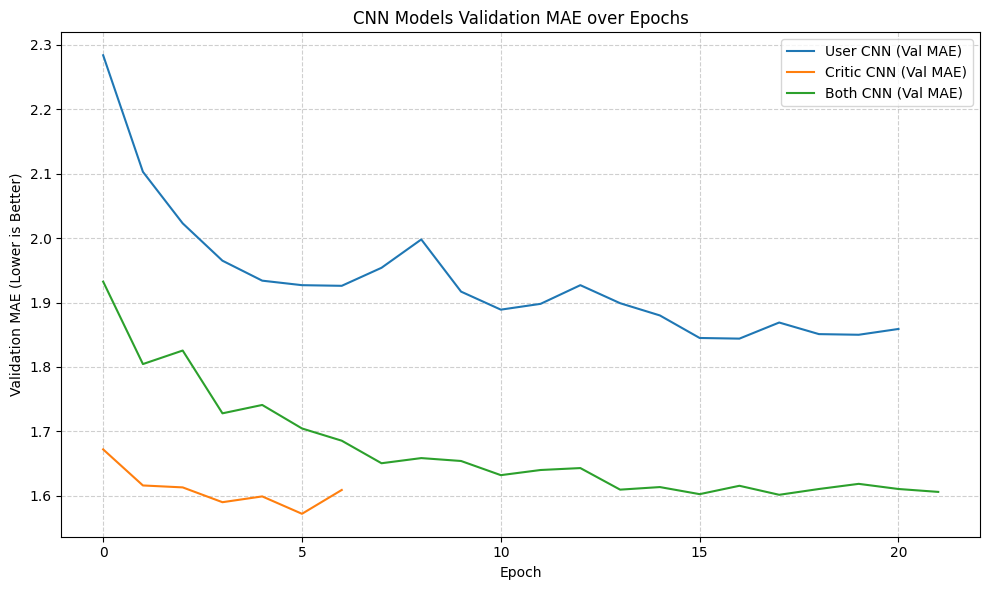

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, history in cnn_histories.items():
    plt.plot(history['val_mae'], label=f'{name} CNN (Val MAE)')

plt.title('CNN Models Validation MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation MAE (Lower is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
custom_reviews = [
    "This movie was an absolute masterpiece! The acting was incredible and the plot was outstanding.",
    "Terrible. Waste of time and money. I do not recommend this to anyone.",
    "It was okay, had some funny moments but felt overall average and predictable."
]

print("=== Custom Quote Predictions (CNN Models) ===\n")
for review in custom_reviews:
    print(f"Review: \"{review}\"")
    for name, model in cnn_models.items():
        vocab = cnn_vocabs[name]
        predicted = predict_score(review, model, vocab, DEVICE)
        print(f"  -> Predicted {name} Score: {predicted}/100")
    print()

=== Custom Quote Predictions (CNN Models) ===

Review: "This movie was an absolute masterpiece! The acting was incredible and the plot was outstanding."
  -> Predicted User Score: 70.60659885406494/100
  -> Predicted Critic Score: 60.10515213012695/100
  -> Predicted Both Score: 54.244089126586914/100

Review: "Terrible. Waste of time and money. I do not recommend this to anyone."
  -> Predicted User Score: -3.8565534353256226/100
  -> Predicted Critic Score: 48.21888446807861/100
  -> Predicted Both Score: 8.968815207481384/100

Review: "It was okay, had some funny moments but felt overall average and predictable."
  -> Predicted User Score: 21.16490364074707/100
  -> Predicted Critic Score: 63.094239234924316/100
  -> Predicted Both Score: 44.551334381103516/100



## Executables

### RNN (CRITICS + USERS)

In [ ]:
models = {}
histories = {}

# Train three independent models.
models["User"] = ScoreClassifier(
    source_vocab_size=len(user_vocab),
    embedding_dim=64,
    hidden_size=64,
)

print("\n" + "=" * 15 + " USER MODEL " + "=" * 15)

histories["User"] = fit_model(
    models["User"],
    user_train_loader,
    user_val_loader,
    epochs=EPOCHS,
)

models["Critic"] = ScoreClassifier(
    source_vocab_size=len(critic_vocab),
    embedding_dim=64,
    hidden_size=64,
)

print("\n" + "=" * 15 + " CRITIC MODEL " + "=" * 15)

histories["Critic"] = fit_model(
    models["Critic"],
    critic_train_loader,
    critic_val_loader,
    epochs=EPOCHS,
)

models["Both"] = ScoreClassifier(
    source_vocab_size=len(both_vocab),
    embedding_dim=64,
    hidden_size=64,
)

print("\n" + "=" * 15 + " BOTH MODEL " + "=" * 15)

histories["Both"] = fit_model(
    models["Both"],
    both_train_loader,
    both_val_loader,
    epochs=EPOCHS,
)

# Evaluate each model after fit_model has restored its best validation checkpoint.
criterion = nn.CrossEntropyLoss()
test_loaders = {
    "User": user_test_loader,
    "Critic": critic_test_loader,
    "Both": both_test_loader,
}

best_results = {}

for name, model in models.items():
    history = histories[name]
    best_index = min(
        range(len(history["val_loss"])),
        key=lambda i: history["val_loss"][i],
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loaders[name],
        criterion,
        DEVICE,
    )

    best_results[name] = {
        "best_epoch": best_index + 1,
        "val_loss": history["val_loss"][best_index],
        "val_mae": history["val_mae"][best_index],
        "test_loss": test_loss,
        "test_mae": test_accuracy,
    }

    print(
        f"{name}: best epoch {best_index + 1} | "
        f"val loss {history['val_loss'][best_index]:.4f} | "
        f"val mae {history['val_mae'][best_index]:.1%} | "
        f"test loss {test_loss:.4f} | "
        f"test mae {test_accuracy:.1%}"
    )


=============== USER MODEL ===============
Epoch 01/50 | train loss 18.6830 | val loss 8.9920 | train mae 3.4759 | val mae 2.4500
Epoch 02/50 | train loss 9.7812 | val loss 8.5245 | train mae 2.5956 | val mae 2.3900
Epoch 03/50 | train loss 9.5614 | val loss 8.5659 | train mae 2.5587 | val mae 2.4380
Epoch 04/50 | train loss 9.3092 | val loss 8.3963 | train mae 2.5084 | val mae 2.3710
Epoch 05/50 | train loss 8.9164 | val loss 8.6579 | train mae 2.4509 | val mae 2.4390
Epoch 06/50 | train loss 8.4348 | val loss 8.2636 | train mae 2.3551 | val mae 2.3080
Epoch 07/50 | train loss 7.8843 | val loss 8.2871 | train mae 2.2641 | val mae 2.2880
Epoch 08/50 | train loss 7.3079 | val loss 7.8810 | train mae 2.1347 | val mae 2.2140
Epoch 09/50 | train loss 6.6414 | val loss 8.2222 | train mae 2.0370 | val mae 2.1940
Epoch 10/50 | train loss 6.2940 | val loss 7.4662 | train mae 1.9681 | val mae 2.1100
Epoch 11/50 | train loss 5.6984 | val loss 7.4313 | train mae 1.8645 | val mae 2.1450
Epoch 12/